# Logistic Regression with scikit-learn

In the previous notebook we implemented logistic regression from scratch:
sigmoid, binary cross-entropy loss, and gradient descent with numpy.
Now we replicate the same experiment using scikit-learn.

The goal is to:
- **Learn the sklearn API** for classification
- **Validate our scratch implementation** by comparing results

Same dataset (`customers.csv`), same features, same 80/20 split.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

### Load data

In [2]:
df = pd.read_csv("data/customers.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8000, 20)


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


### Features and target

In [3]:
feature_cols = [
    "age", "total_orders", "total_spend_usd", "avg_order_value_usd",
    "days_since_last_purchase", "reviews_given", "avg_review_score",
    "returns_made", "wishlist_items", "newsletter_subscribed"
]

X = df[feature_cols].values.astype(float)
y = df["churned"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (6400, 10)
Test:  (1600, 10)


### Normalize features

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Mean  (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std   (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Mean  (should be ~0): [ 0. -0.  0.  0.  0.  0. -0.  0.  0.  0.]
Std   (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## LogisticRegression

In [5]:
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_scaled, y_train)

print(f"Intercept: {clf.intercept_[0]:.4f}")
print(f"\nCoefficients:")
for name, coef in zip(feature_cols, clf.coef_[0]):
    print(f"  {name:<30} {coef:.4f}")

Intercept: -2.5506

Coefficients:
  age                            -0.0198
  total_orders                   -0.4567
  total_spend_usd                0.1512
  avg_order_value_usd            -0.1032
  days_since_last_purchase       0.4762
  reviews_given                  -0.0876
  avg_review_score               -0.0568
  returns_made                   -0.0031
  wishlist_items                 -0.0029
  newsletter_subscribed          0.0717


### Predict

In [6]:
y_pred = clf.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

Accuracy:  0.8950
Precision: 0.6000
Recall:    0.0178
F1:        0.0345


### Confusion matrix

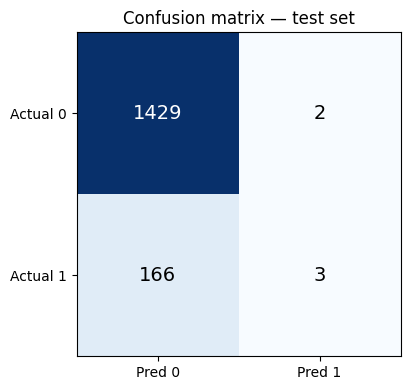

In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

### Coefficients

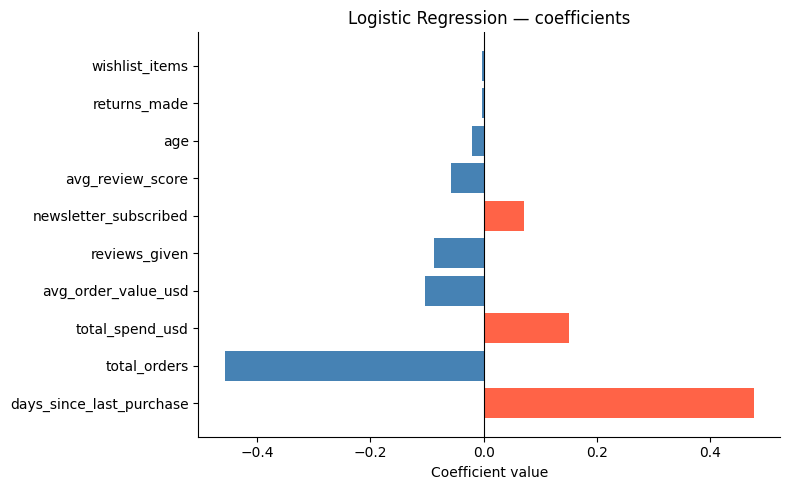

In [8]:
coefs = clf.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))[::-1]

plt.figure(figsize=(8, 5))
plt.barh(
    [feature_cols[i] for i in sorted_idx],
    coefs[sorted_idx],
    color=["tomato" if c > 0 else "steelblue" for c in coefs[sorted_idx]]
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — coefficients")
plt.xlabel("Coefficient value")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Summary

Comparing scratch implementation vs sklearn:

In [ ]:
scratch = {"accuracy": 0.9175, "precision": 0.5000, "recall": 0.0152, "f1": 0.0294}

print(f"{'Metric':<12} {'Scratch':>10} {'sklearn':>10}")
print("─" * 34)
print(f"{'Accuracy':<12} {scratch['accuracy']:>10.4f} {accuracy:>10.4f}")
print(f"{'Precision':<12} {scratch['precision']:>10.4f} {precision:>10.4f}")
print(f"{'Recall':<12} {scratch['recall']:>10.4f} {recall:>10.4f}")
print(f"{'F1':<12} {scratch['f1']:>10.4f} {f1:>10.4f}")

Metric          Scratch    sklearn
──────────────────────────────────
Accuracy         0.9175     0.8950
Precision        0.5000     0.6000
Recall           0.0152     0.0178
F1               0.0294     0.0345
